In [1]:
from pyDOE import lhs
import numpy as np
import scipy.io
import time
import torch
from collections import OrderedDict
import numpy as np
import torch 
from pyhessian import hessian
from pyhessian import * # get the dataset
# from pyhessian import hessian # Hessian computation
# from density_plot import get_esd_plot # ESD plot
# from pytorchcv.model_provider import get_model as ptcv_get_model # model
seed=42
np.random.seed(seed)
torch.manual_seed(seed)
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
device = "cuda"

# deep neural network
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        self.depth = len(layers) - 1

        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        self.layers = torch.nn.Sequential(layerDict)

        for module in self.layers.modules():
            if isinstance(module, torch.nn.Linear):
                torch.nn.init.xavier_normal_(module.weight)

    def forward(self, x):
        out = self.layers(x)
        return out

class PhysicsInformedNN():
    def __init__(self, X_u, u, X_f, c, all_x, all_t, layers, lb, ub):

        # boundary conditions
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        # x and t data for states and collocation points
        self.x_u = torch.tensor(X_u[:, 0:1], requires_grad=True).float().to(device)
        self.t_u = torch.tensor(X_u[:, 1:2], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.all_x = torch.tensor(all_x).float().to(device)
        self.all_t = torch.tensor(all_t).float().to(device)
        self.delta_x = 1/128
        # state data
        self.u = torch.tensor(u).float().to(device)
        # conserved quantity
        self.c = c

        self.layers = layers

        self.dnn = DNN(layers).to(device)

        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"
        )

        self.iter = 0
        self.u_losses = []
        self.f_losses = []

        self.losses = []
        self.gradients = None
        self.solutions = None

    def net_u(self, x, t):

        u = self.dnn(torch.cat([x, t], dim=1))

        # return u

        mesh_t, mesh_x = torch.meshgrid([t.squeeze(1).detach(), self.all_x.detach()], indexing='ij')
        t_by_x = torch.concat((mesh_x.unsqueeze(2), mesh_t.unsqueeze(2)), dim=-1)

        # use integral on mesh to find current momentum of system
        if t.shape[0] == 100:
            integral_u_dx = torch.sum(self.dnn(t_by_x)**2*self.delta_x, dim=1).to(device)
        else:
            integral_u_dx = []
            n_batches = 10
            batch_size = int(t.shape[0]/n_batches)
            for i in range(0, t.shape[0], batch_size):
                integral_part = torch.sum(self.dnn(t_by_x[i:i+batch_size, :, :])**2*self.delta_x, dim=1)
                integral_u_dx.append(integral_part)

            integral_u_dx = torch.cat(integral_u_dx, dim=0)

        projection = torch.sqrt(self.c/integral_u_dx).to(device)
        projected_u = projection * u

        return projected_u
        # return u


    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t)
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        # advection equation
        f = u_t + 0.25 * u_x
        return f

    def loss_func(self, X_u_train, u_train, X_f_train):
        self.optimizer.zero_grad()

        x_u = torch.tensor(X_u_train[:, 0:1], requires_grad=True).float().to(device)
        t_u = torch.tensor(X_u_train[:, 1:2], requires_grad=True).float().to(device)
        x_f = torch.tensor(X_f_train[:, 0:1], requires_grad=True).float().to(device)
        t_f = torch.tensor(X_f_train[:, 1:2], requires_grad=True).float().to(device)
        u = torch.tensor(u_train).float().to(device)


        u_pred = self.net_u(x_u, t_u)
        f_pred = self.net_f(x_f, t_f)
        loss_u = torch.mean((u - u_pred) ** 2)
        loss_f = torch.mean(f_pred ** 2)

        self.u_losses.append(loss_u.item())
        self.f_losses.append(loss_f.item())

        loss = loss_u + loss_f

        # loss.backward()

        self.iter += 1
        if self.iter % 100 == 0:
            print(
                'Iter %d, Loss: %.5e, Loss_u: %.5e, Loss_f: %.5e' % (self.iter, loss.item(), loss_u.item(), loss_f.item())
            )

        return loss

    def train(self):
        self.dnn.train()

        self.optimizer.step(self.loss_func)


    def predict(self, X):
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device)
        t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)

        self.dnn.eval()
        u = self.net_u(x, t)
        f = self.net_f(x, t)
        c = torch.sum(torch.reshape(u, (100, 256))*self.delta_x, dim=1)
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy()
        c = c.detach().cpu().numpy()
        return u, f, c

In [3]:

layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

N_u = 100
N_f = 10000

data = np.load('../advection_solution.npy', allow_pickle=True).item()

# Extract the saved arrays
x = data['x']
t = data['t']
Exact = data['u']

X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
u_star = Exact.flatten()[:,None]

lb = X_star.min(0)
ub = X_star.max(0)

# boundary points
xx1 = np.hstack((X[0:1,:].T, T[0:1,:].T))
uu1 = Exact[0:1,:].T
xx2 = np.hstack((X[:,0:1], T[:,0:1]))
uu2 = Exact[:,0:1]
xx3 = np.hstack((X[:,-1:], T[:,-1:]))
uu3 = Exact[:,-1:]

X_u_train = np.vstack([xx1, xx2, xx3])
X_f_train = lb + (ub-lb)*lhs(2, N_f)

# conserved quantity
c = np.mean(np.sum(Exact**2*1/128, axis=1))

X_f_train = np.vstack((X_f_train, X_u_train))
u_train = np.vstack([uu1, uu2, uu3])

# take random sample of data
idx = np.random.choice(X_u_train.shape[0], N_u, replace=False)
X_u_train = X_u_train[idx, :]
u_train = u_train[idx,:]

model = PhysicsInformedNN(X_u_train, u_train, X_f_train, c, x, t, layers, lb, ub)

# Load the saved parameters
model.dnn.load_state_dict(torch.load('pinn_proj_energy.pth'))
model.dnn.eval()

DNN(
  (layers): Sequential(
    (layer_0): Linear(in_features=2, out_features=20, bias=True)
    (activation_0): Tanh()
    (layer_1): Linear(in_features=20, out_features=20, bias=True)
    (activation_1): Tanh()
    (layer_2): Linear(in_features=20, out_features=20, bias=True)
    (activation_2): Tanh()
    (layer_3): Linear(in_features=20, out_features=20, bias=True)
    (activation_3): Tanh()
    (layer_4): Linear(in_features=20, out_features=20, bias=True)
    (activation_4): Tanh()
    (layer_5): Linear(in_features=20, out_features=20, bias=True)
    (activation_5): Tanh()
    (layer_6): Linear(in_features=20, out_features=20, bias=True)
    (activation_6): Tanh()
    (layer_7): Linear(in_features=20, out_features=20, bias=True)
    (activation_7): Tanh()
    (layer_8): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

X_u_train_tensor = torch.tensor(X_u_train, dtype=torch.float32).to(device)
u_train_tensor = torch.tensor(u_train, dtype=torch.float32).to(device)

hessian_comp = hessian(model, data=(X_u_train_tensor, u_train_tensor, X_f_train), cuda=True)

top_eigenvalues, top_eigenvector = hessian_comp.eigenvalues(top_n=2)
print(f"The top Hessian eigenvalue of this model is {top_eigenvalues}")

def get_params(model_orig,  model_perb, direction, alpha):
    for m_orig, m_perb, d in zip(model_orig.parameters(), model_perb.parameters(), direction):
        m_perb.data = m_orig.data + alpha * d
    return model_perb

                        

The top Hessian eigenvalue of this model is [7.848503112792969, 3.5880651473999023]


In [5]:
# import tqdm
# # lambda is a small scalar that we use to perturb the model parameters along the eigenvectors 
# lams1 = np.linspace(-2, 2, 50).astype(np.float32)
# lams2 = np.linspace(-2, 2, 50).astype(np.float32)

# loss_list = []

# # create a copy of the model
# model_perb1 = PhysicsInformedNN(X_u_train, u_train, X_f_train, c, x, t, layers, lb, ub)
# model_perb1.dnn.load_state_dict(torch.load('pinn_proj.pth'))
# model_perb1.dnn.eval()

# model_perb2 = PhysicsInformedNN(X_u_train, u_train, X_f_train, c, x, t, layers, lb, ub)
# model_perb2.dnn.load_state_dict(torch.load('pinn_proj.pth'))
# model_perb2.dnn.eval()


# model_perb1 = model_perb1.dnn
# model_perb2 = model_perb2.dnn


# for lam1 in tqdm.tqdm(lams1):
#     for lam2 in lams2:
#         model_perb1 = get_params(model.dnn, model_perb1, top_eigenvector[0], lam1)
#         model_perb2 = get_params(model_perb1, model_perb2, top_eigenvector[1], lam2)

#         perb_pinn = PhysicsInformedNN(X_u_train, u_train, X_f_train, c, x, t, layers, lb, ub)
#         perb_pinn.dnn = model_perb2

#         loss_list.append((lam1, lam2, perb_pinn.loss_func(*(X_u_train_tensor, u_train_tensor, X_f_train)).item()))   

# loss_list = np.array(loss_list)

In [6]:
# # Create interactive 3D plot with colors based on Z values
# fig = go.Figure(data=[go.Mesh3d(
#     x=loss_list[:,0],
#     y=loss_list[:,1], 
#     z=loss_list[:,2],
#     intensity=loss_list[:,2],  # This makes colors follow Z values
#     opacity=0.8,
#     colorscale='RdYlBu',
#     colorbar=dict(title="Loss")  # Add colorbar
# )])

# fig.update_layout(
#     title='Interactive Loss Landscape',
#     scene=dict(
#         xaxis_title='ε_1',
#         yaxis_title='ε_2',
#         zaxis_title='Loss'
#     )
# )

# fig.show()

In [7]:
# top_eigenvalues, top_eigenvector = hessian_comp.eigenvalues(top_n=50)
# print(top_eigenvalues)

K: 2.1873914743383076


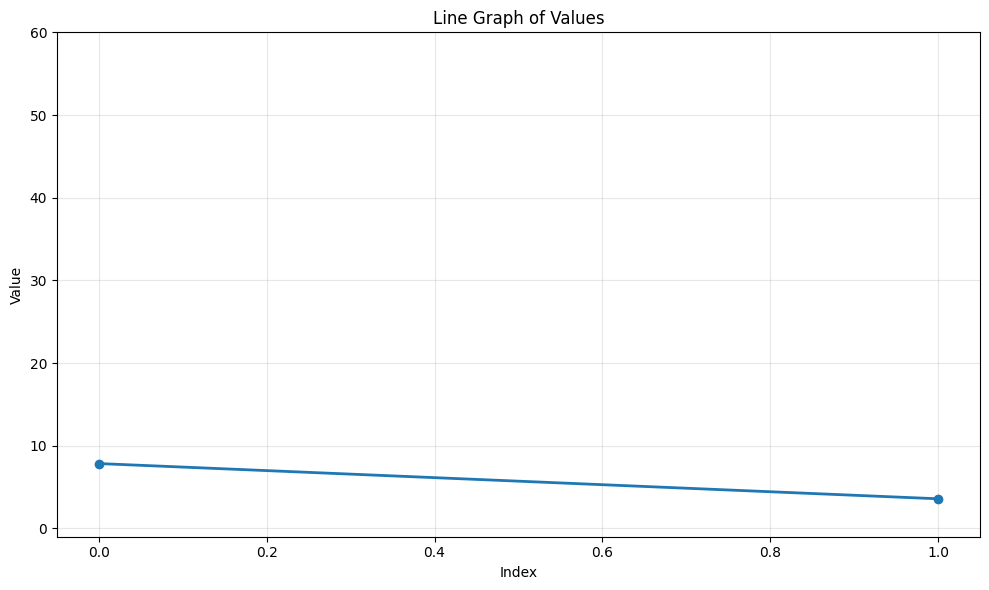

In [8]:
import matplotlib.pyplot as plt

abs_top_eigenvalues = np.abs(np.array(top_eigenvalues))

# Create x-axis values (indices)
x = list(range(len(top_eigenvalues)))

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(x, top_eigenvalues, marker='o', linewidth=2, markersize=6)

# Add labels and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Line Graph of Values')

# Add grid for better readability
plt.grid(True, alpha=0.3)

print("K:", np.max(abs_top_eigenvalues)/np.min(abs_top_eigenvalues))

plt.ylim(-1, 60)

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np
# eigen_list_full, weight_list_full = hessian_comp.density()
# # Combine all runs
# eigenvals = np.concatenate([np.array(run) for run in eigen_list_full])
# weights = np.concatenate([np.array(run) for run in weight_list_full])

# # Create weighted histogram
# plt.hist(eigenvals, weights=weights, bins=100, density=True)
# plt.xlabel('Eigenvalue')
# plt.ylabel('Density')
# plt.yscale('log')  # This makes y-axis logarithmic
# plt.title('Hessian Eigenvalue Density')

In [10]:
import pickle
eigen_list_full, weight_list_full = hessian_comp.density(iter=100, n_v=10)


results = {
    'eigen_list_full': eigen_list_full,
    'weight_list_full': weight_list_full
}

# with open('adv_energy.pkl', 'wb') as f:
#     pickle.dump(results, f)
print(results)

{'eigen_list_full': [[np.complex64(7.8523464+0j), np.complex64(3.5919034+0j), np.complex64(2.3000286+0j), np.complex64(1.082661+0j), np.complex64(0.36044583+0j), np.complex64(0.69157857+0j), np.complex64(0.17363384+0j), np.complex64(0.103719495+0j), np.complex64(0.08524683+0j), np.complex64(0.03999096+0j), np.complex64(0.019033834+0j), np.complex64(0.010004897+0j), np.complex64(0.0059528686+0j), np.complex64(0.0051536276+0j), np.complex64(0.003897728+0j), np.complex64(2.9763074+0j), np.complex64(-2.1974142+0j), np.complex64(-2.067284+0j), np.complex64(2.2119598+0j), np.complex64(2.079176+0j), np.complex64(1.7660959+0j), np.complex64(1.5825378+0j), np.complex64(2.4821534+0j), np.complex64(-1.7433724+0j), np.complex64(1.1857395+0j), np.complex64(-1.5531299+0j), np.complex64(1.0240872+0j), np.complex64(-1.1571351+0j), np.complex64(-1.0024259+0j), np.complex64(0.8552429+0j), np.complex64(-0.5037159+0j), np.complex64(0.6013702+0j), np.complex64(0.44997406+0j), np.complex64(0.5111398+0j), np

In [11]:
with open('adv_energy.pkl', 'wb') as f:
    pickle.dump(results, f)

In [12]:
# eigen_list_full2, weight_list_full2 = hessian_comp.density(iter=100, n_v=10)


In [13]:
# print(eigen_list_full2)